### Library Importations & GPU Verification

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU Available: []


### Data Streamers Configuration

In [4]:
# Image parameters
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
PLANTVILLAGE_DIR = 'plantvillage dataset/color'

# Augmentation for training dataset
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    PLANTVILLAGE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    PLANTVILLAGE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"Target Disease Classes Identified: {num_classes}")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Target Disease Classes Identified: 38


### Build MobileNetV2 CNN Architecture

In [5]:
# Load pre-trained MobileNetV2 without top classification head
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base model layers for feature extraction
base_model.trainable = False

# Add custom dense classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Define Callbacks & Train CNN

In [6]:
# Set up callbacks to optimize convergence and save best weights
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ModelCheckpoint('models/saved_models/cnn_leaf_model_best.h5', monitor='val_accuracy', save_best_only=True)
]

# Train top layers
EPOCHS = 10
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8174 - loss: 0.6072

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2065s 2s/step - accuracy: 0.8174 - loss: 0.6072 - val_accuracy: 0.9046 - val_loss: 0.2871 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8898 - loss: 0.3333

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2023s 1s/step - accuracy: 0.8898 - loss: 0.3333 - val_accuracy: 0.9188 - val_loss: 0.2458 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9019 - loss: 0.2973

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1956s 1s/step - accuracy: 0.9019 - loss: 0.2973 - val_accuracy: 0.9205 - val_loss: 0.2349 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9070 - loss: 0.2754

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1953s 1s/step - accuracy: 0.9070 - loss: 0.2754 - val_accuracy: 0.9246 - val_loss: 0.2216 - learning_rate: 0.0010
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9135 - loss: 0.2568

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1979s 1s/step - accuracy: 0.9135 - loss: 0.2568 - val_accuracy: 0.9330 - val_loss: 0.1946 - learning_rate: 0.0010
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2035s 1s/step - accuracy: 0.9177 - loss: 0.2456 - val_accuracy: 0.9280 - val_loss: 0.2146 - learning_rate: 0.0010
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2024s 1s/step - accuracy: 0.9213 - loss: 0.2373 - val_accuracy: 0.9327 - val_loss: 0.2054 - learning_rate: 0.0010
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9411 - loss: 0.1753

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1986s 1s/step - accuracy: 0.9411 - loss: 0.1753 - val_accuracy: 0.9497 - val_loss: 0.1497 - learning_rate: 2.0000e-04
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9448 - loss: 0.1601

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2025s 1s/step - accuracy: 0.9448 - loss: 0.1601 - val_accuracy: 0.9511 - val_loss: 0.1397 - learning_rate: 2.0000e-04
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9455 - loss: 0.1559

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2111s 2s/step - accuracy: 0.9455 - loss: 0.1559 - val_accuracy: 0.9511 - val_loss: 0.1444 - learning_rate: 2.0000e-04


In [7]:
# import os
# import tensorflow as tf

# model_path = 'models/saved_models/cnn_leaf_model_best.h5'

# if os.path.exists(model_path):
#     # Load the saved model weights
#     model = tf.keras.models.load_model(model_path)
#     print("Successfully loaded saved model checkpoint!")
    
#     # Save a copy as final model
#     model.save('models/saved_models/cnn_leaf_model_final.h5')
#     print("Final model saved as 'models/saved_models/cnn_leaf_model_final.h5'.")
# else:
#     print("Checkpoint file not found. Check if training completed or check your folder path.")

In [9]:
import tensorflow as tf

# Load saved model file
cnn_model = tf.keras.models.load_model('models/saved_models/cnn_leaf_model_best.h5')

# Run prediction
val_generator.reset()
y_probs = cnn_model.predict(val_generator, verbose=1)

340/340 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    accuracy_score, 
    precision_recall_fscore_support
)

# ==================== 1. MODEL PREDICTIONS ====================
# Replace `val_generator` with your validation/test data generator or (X_test, y_test)
# Make sure shuffle=False on your test generator so indices match!
val_generator.reset()
y_probs = cnn_model.predict(val_generator, verbose=1)

# Extract true labels and predicted class indices
if hasattr(val_generator, 'classes'):
    y_true = val_generator.classes
    class_names = list(val_generator.class_indices.keys())
else:
    # If using numpy arrays (X_test, y_test)
    y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test
    class_names = [f"Class_{i}" for i in range(y_probs.shape[1])]

num_classes = len(class_names)

if num_classes == 2 and y_probs.ndim == 2 and y_probs.shape[1] == 1:
    y_pred = (y_probs > 0.5).astype(int).ravel()
    y_probs_roc = y_probs.ravel()
else:
    y_pred = np.argmax(y_probs, axis=1)
    y_probs_roc = y_probs

# ==================== 2. OVERALL KPI METRICS ====================
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print("="*60)
print("               MODEL PERFORMANCE OVERVIEW")
print("="*60)
print(f"Overall Accuracy : {acc:.2%}")
print(f"Weighted Precision: {prec:.2%}")
print(f"Weighted Recall   : {rec:.2%}")
print(f"Weighted F1-Score : {f1:.2%}")
print("="*60 + "\n")

# ==================== 3. DETAILED CLASSIFICATION REPORT ====================
print("CLASSIFICATION REPORT:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Convert to DataFrame for a clean visual table display in Jupyter
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).T
display(report_df.style.background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

340/340 ━━━━━━━━━━━━━━━━━━━━ 452s 1s/step
               MODEL PERFORMANCE OVERVIEW
Overall Accuracy : 95.21%
Weighted Precision: 95.22%
Weighted Recall   : 95.21%
Weighted F1-Score : 95.16%

CLASSIFICATION REPORT:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9453    0.9603    0.9528       126
                                 Apple___Black_rot     0.9756    0.9677    0.9717       124
                          Apple___Cedar_apple_rust     1.0000    0.9636    0.9815        55
                                   Apple___healthy     0.9878    0.9878    0.9878       329
                               Blueberry___healthy     0.9708    0.9967    0.9836       300
          Cherry_(including_sour)___Powdery_mildew     0.9810    0.9857    0.9834       210
                 Cherry_(including_sour)___healthy     0.9881    0.9765    0.9822       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_sp

,precision,recall,f1-score,support
Apple___Apple_scab,0.945312,0.960317,0.952756,126.000000
Apple___Black_rot,0.975610,0.967742,0.971660,124.000000
Apple___Cedar_apple_rust,1.000000,0.963636,0.981481,55.000000
Apple___healthy,0.987842,0.987842,0.987842,329.000000
Blueberry___healthy,0.970779,0.996667,0.983553,300.000000
Cherry_(including_sour)___Powdery_mildew,0.981043,0.985714,0.983373,210.000000
Cherry_(including_sour)___healthy,0.988095,0.976471,0.982249,170.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.790909,0.852941,0.820755,102.000000
Corn_(maize)___Common_rust_,1.000000,0.987395,0.993658,238.000000
Corn_(maize)___Northern_Leaf_Blight,0.914894,0.873096,0.893506,197.000000


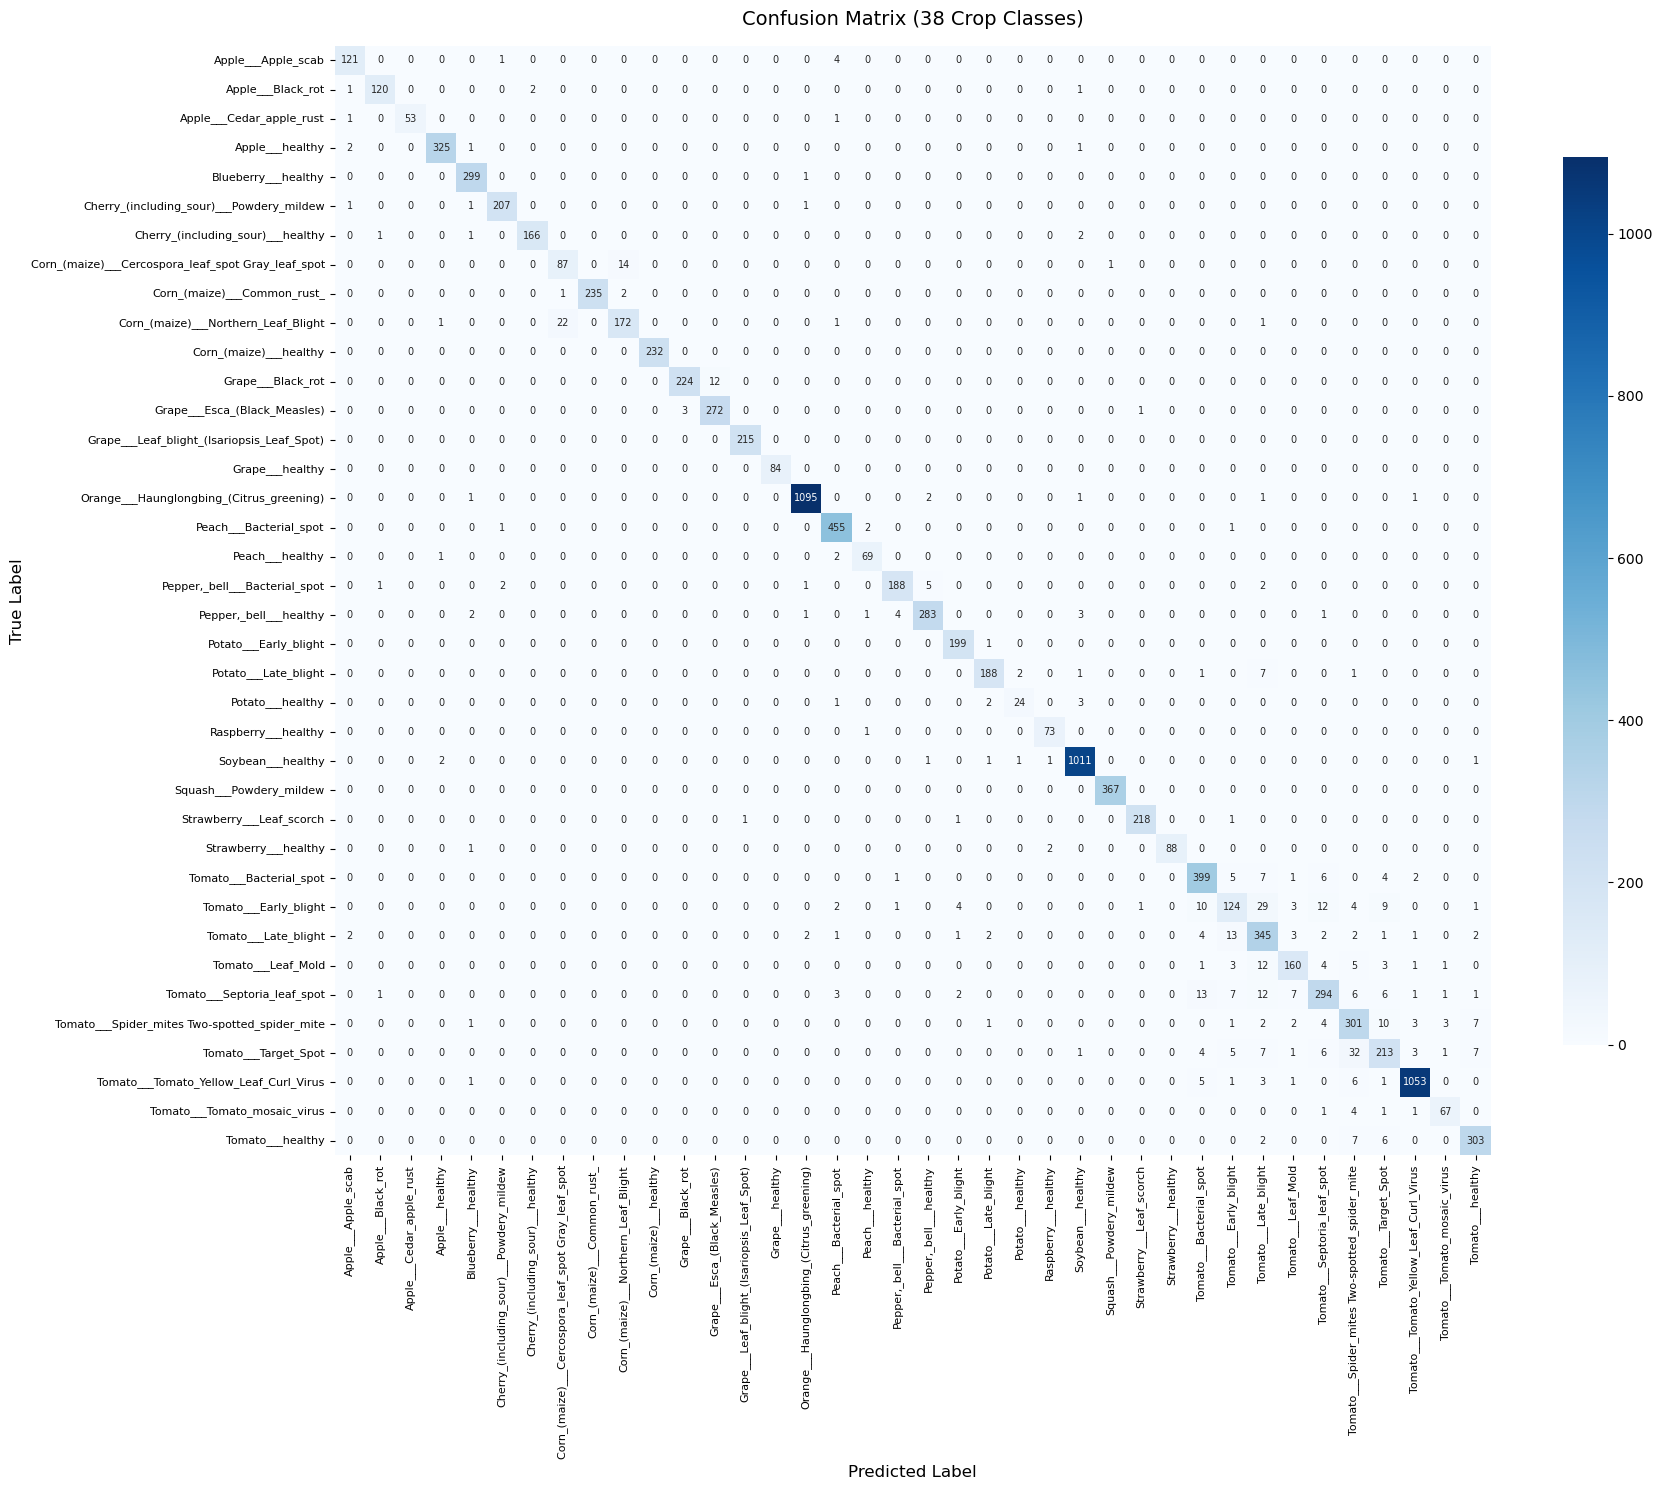

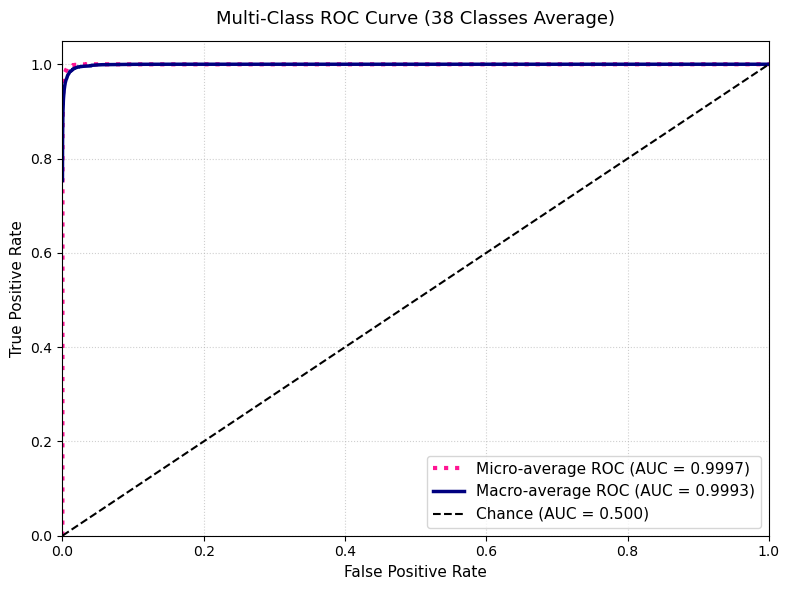

In [20]:
from sklearn.preprocessing import label_binarize

# ==================== 4. CLEAN VISUALIZATIONS (38-CLASS OPTIMIZED) ====================

# --- PLOT A: EXPANDED CONFUSION MATRIX ---
plt.figure(figsize=(18, 15))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    annot_kws={"size": 7},  # Small readable numbers inside cells
    cbar_kws={'shrink': 0.8}
)

plt.title('Confusion Matrix (38 Crop Classes)', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# --- PLOT B: MICRO & MACRO AVERAGE ROC CURVE ---
plt.figure(figsize=(8, 6))

# Binarize ground truth labels across all 38 classes
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# 1. Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# 2. Macro-average ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_probs[:, i])[0] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= num_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot clean average ROC curves
plt.plot(fpr_micro, tpr_micro, label=f'Micro-average ROC (AUC = {roc_auc_micro:.4f})', color='deeppink', linestyle=':', lw=3)
plt.plot(all_fpr, mean_tpr, label=f'Macro-average ROC (AUC = {roc_auc_macro:.4f})', color='navy', linestyle='-', lw=2.5)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Multi-Class ROC Curve (38 Classes Average)', fontsize=13, pad=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()